In [1]:

from google.colab import files
from IPython.display import display
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

uploaded = files.upload()

csv_files = [file for file in os.listdir() if file.endswith(".csv")]

if len(csv_files) == 0:
    raise FileNotFoundError("No CSV file was uploaded.")

FILE_PATH = csv_files[0]
OUTPUT_DIR = "eda_results"

os.makedirs(OUTPUT_DIR, exist_ok=True)

df = pd.read_csv(FILE_PATH)

df.columns = df.columns.astype(str).str.strip()

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

print("=" * 80)
print("DATASET LOADED SUCCESSFULLY")
print("=" * 80)

print("Loaded file:", FILE_PATH)
print("Dataset shape:", df.shape)

display(df.head())

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes)

Saving kolesa.csv to kolesa.csv
DATASET LOADED SUCCESSFULLY
Loaded file: kolesa.csv
Dataset shape: (2754, 10)


,title,brand,model,price,year,body_type,volume,fuel,gearbox,type
0,BMW X5,BMW,X5,8000000,2013,кроссовер,3.00,бензин,автомат,Б/у
1,BMW 535,BMW,535,10500000,2012,седан,3.00,бензин,автомат,Б/у
2,BMW 528,BMW,528,1435555,1991,седан,2.80,бензин,механика,Б/у
3,BMW X5,BMW,X5,13500000,2014,кроссовер,3.00,бензин,автомат,Б/у
4,BMW 316,BMW,316,650000,1994,купе,1.60,бензин,механика,Б/у



Column names:
['title', 'brand', 'model', 'price', 'year', 'body_type', 'volume', 'fuel', 'gearbox', 'type']

Data types:


,0
title,object
brand,object
model,object
price,int64
year,int64
body_type,object
volume,float64
fuel,object
gearbox,object
type,object


In [2]:


important_numeric_cols = ["price", "year", "volume"]

for col in important_numeric_cols:
    if col in df.columns:
        df[col] = (
            df[col]
            .astype(str)
            .str.replace(" ", "", regex=False)
            .str.replace(",", ".", regex=False)
            .str.replace("₸", "", regex=False)
            .str.replace("тг", "", regex=False)
        )
        df[col] = pd.to_numeric(df[col], errors="coerce")

if "year" in df.columns:
    df["car_age"] = 2026 - df["year"]

print("\nData types after conversion:")
display(df.dtypes)


Data types after conversion:


,0
title,object
brand,object
model,object
price,int64
year,int64
body_type,object
volume,float64
fuel,object
gearbox,object
type,object


In [3]:


print("=" * 80)
print("DATA QUALITY CHECK")
print("=" * 80)

missing_values = df.isnull().sum()
missing_percent = (df.isnull().mean() * 100).round(2)
duplicates = df.duplicated().sum()

missing_table = pd.DataFrame({
    "missing_count": missing_values,
    "missing_percent": missing_percent
})

print("\nMissing values:")
display(missing_table)

print("\nDuplicate rows:")
print(duplicates)

missing_table.to_csv(f"{OUTPUT_DIR}/missing_values.csv")

DATA QUALITY CHECK

Missing values:


,missing_count,missing_percent
title,0,0.00
brand,0,0.00
model,0,0.00
price,0,0.00
year,0,0.00
body_type,0,0.00
volume,0,0.00
fuel,0,0.00
gearbox,0,0.00
type,0,0.00



Duplicate rows:
0


In [4]:


numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("=" * 80)
print("COLUMN TYPES")
print("=" * 80)

print("Numerical columns:")
print(numeric_cols)

print("\nCategorical columns:")
print(categorical_cols)

COLUMN TYPES
Numerical columns:
['price', 'year', 'volume', 'car_age']

Categorical columns:
['title', 'brand', 'model', 'body_type', 'fuel', 'gearbox', 'type']


In [5]:


print("=" * 80)
print("DESCRIPTIVE STATISTICS")
print("=" * 80)

if len(numeric_cols) > 0:
    desc_stats = pd.DataFrame({
        "mean": df[numeric_cols].mean(),
        "median": df[numeric_cols].median(),
        "mode": df[numeric_cols].mode().iloc[0],
        "std": df[numeric_cols].std(),
        "min": df[numeric_cols].min(),
        "25%": df[numeric_cols].quantile(0.25),
        "50%": df[numeric_cols].quantile(0.50),
        "75%": df[numeric_cols].quantile(0.75),
        "max": df[numeric_cols].max()
    })

    display(desc_stats)
    display(df[numeric_cols].describe())

    desc_stats.to_csv(f"{OUTPUT_DIR}/descriptive_statistics.csv")
    df[numeric_cols].describe().to_csv(f"{OUTPUT_DIR}/pandas_describe.csv")

DESCRIPTIVE STATISTICS


,mean,median,mode,std,min,25%,50%,75%,max
price,"12,082,964.80","5,700,000.00","3,500,000.00","16,128,960.68","200,000.00","2,600,000.00","5,700,000.00","13,974,250.00","120,000,000.00"
year,"2,005.34","2,004.00","1,993.00",10.77,"1,981.00","1,995.00","2,004.00","2,015.00","2,026.00"
volume,2.83,3.00,3.00,0.76,0.70,2.00,3.00,3.00,6.60
car_age,20.66,22.00,33.00,10.77,0.00,11.00,22.00,31.00,45.00


,price,year,volume,car_age
count,"2,754.00","2,754.00","2,754.00","2,754.00"
mean,"12,082,964.80","2,005.34",2.83,20.66
std,"16,128,960.68",10.77,0.76,10.77
min,"200,000.00","1,981.00",0.70,0.00
25%,"2,600,000.00","1,995.00",2.00,11.00
50%,"5,700,000.00","2,004.00",3.00,22.00
75%,"13,974,250.00","2,015.00",3.00,31.00
max,"120,000,000.00","2,026.00",6.60,45.00


In [6]:


print("=" * 80)
print("CATEGORICAL VARIABLES SUMMARY")
print("=" * 80)

for col in categorical_cols:
    print("\n" + "-" * 80)
    print(f"Column: {col}")
    print(f"Unique values: {df[col].nunique()}")
    print("Top 10 values:")
    display(df[col].value_counts().head(10))

    safe_col = col.replace("/", "_").replace("\\", "_").replace(" ", "_")

    df[col].value_counts().head(20).to_csv(
        f"{OUTPUT_DIR}/top_values_{safe_col}.csv",
        header=["count"]
    )

CATEGORICAL VARIABLES SUMMARY

--------------------------------------------------------------------------------
Column: title
Unique values: 74
Top 10 values:


,count
title,
BMW X5,452
BMW 525,324
BMW 530,218
BMW 520,205
BMW 528,186
BMW X6,113
BMW 320,101
BMW 318,91
BMW 535,83



--------------------------------------------------------------------------------
Column: brand
Unique values: 1
Top 10 values:


,count
brand,
BMW,2754



--------------------------------------------------------------------------------
Column: model
Unique values: 74
Top 10 values:


...

,count
fuel,
бензин,2664
дизель,43
газ-бензин,24
гибрид,23



--------------------------------------------------------------------------------
Column: gearbox
Unique values: 4
Top 10 values:


,count
gearbox,
автомат,2030
механика,704
робот,19
вариатор,1



--------------------------------------------------------------------------------
Column: type
Unique values: 2
Top 10 values:


,count
type,
Б/у,2742
новый,12


DISTRIBUTION ANALYSIS

Column: price
Skewness: 2.579


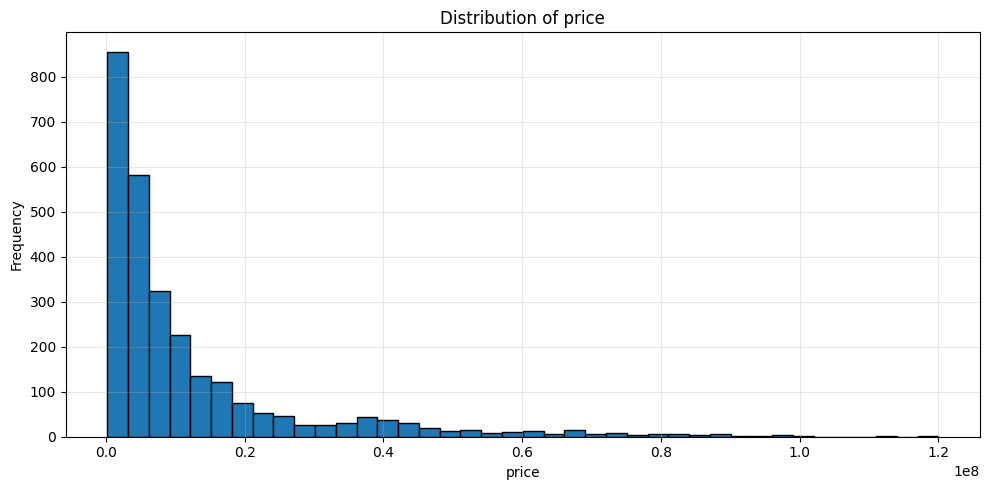

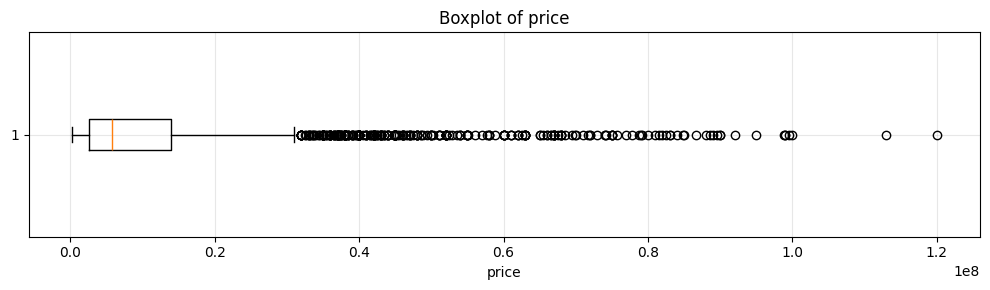


Column: year
Skewness: 0.162


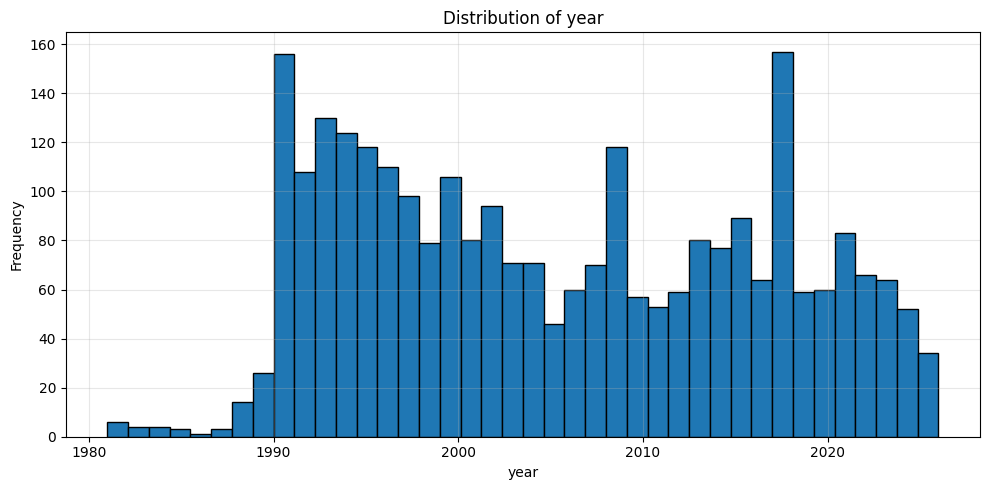

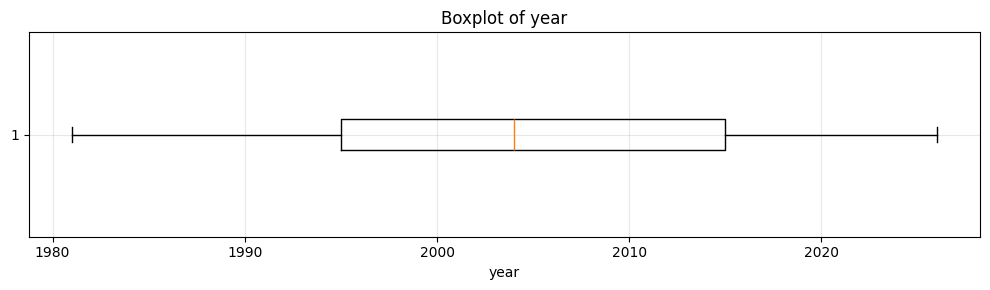


Column: volume
Skewness: 1.0


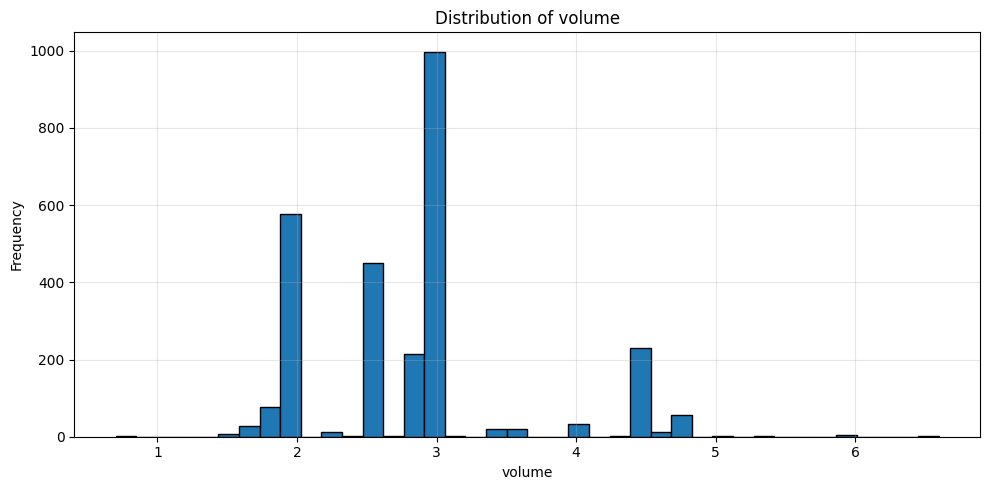

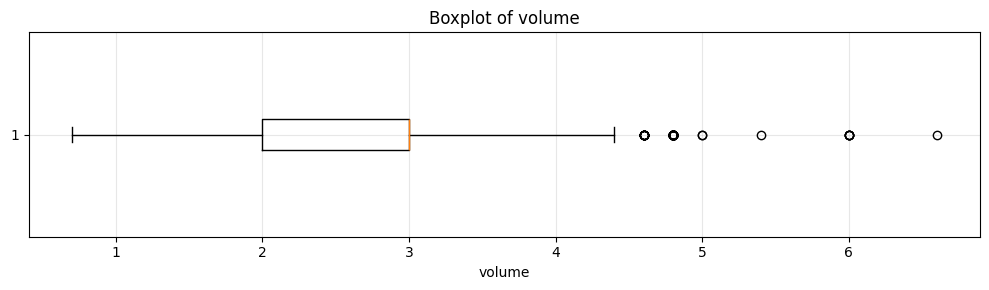


Column: car_age
Skewness: -0.162


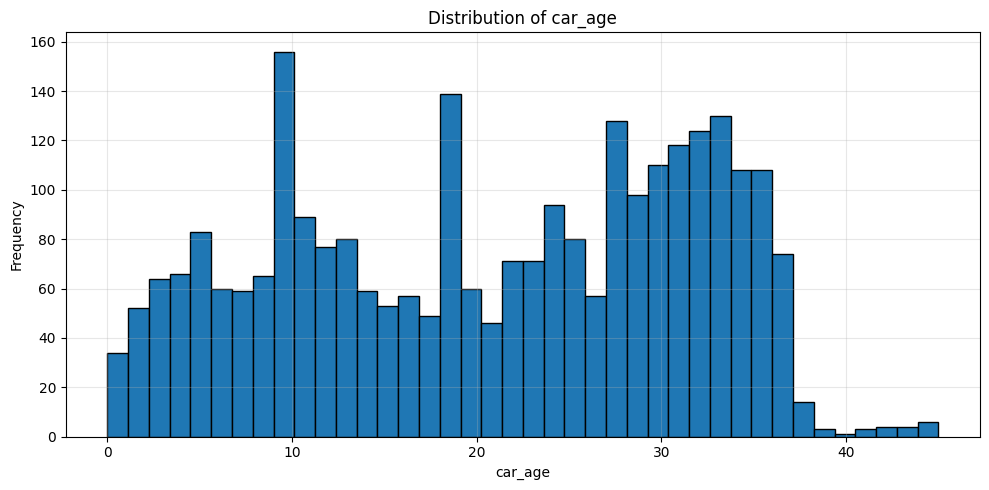

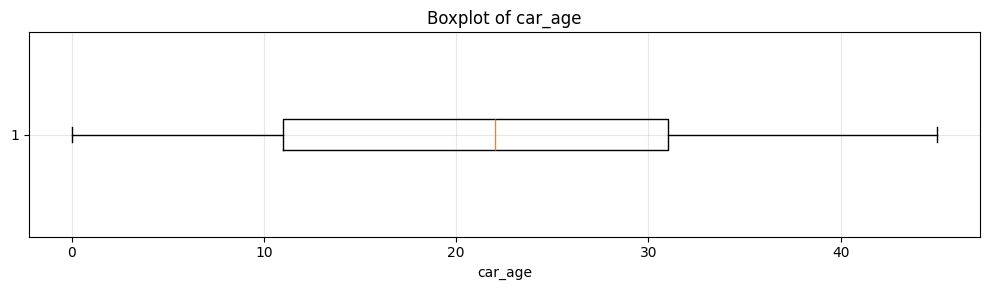

In [7]:


print("=" * 80)
print("DISTRIBUTION ANALYSIS")
print("=" * 80)

for col in numeric_cols:
    data = df[col].dropna()

    if len(data) == 0:
        continue

    print(f"\nColumn: {col}")
    print(f"Skewness: {round(data.skew(), 3)}")

    safe_col = col.replace("/", "_").replace("\\", "_").replace(" ", "_")

    plt.figure(figsize=(10, 5))
    plt.hist(data, bins=40, edgecolor="black")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/distribution_{safe_col}.png", dpi=300)
    plt.show()

    plt.figure(figsize=(10, 3))
    plt.boxplot(data, vert=False)
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/boxplot_{safe_col}.png", dpi=300)
    plt.show()

PRICE DISTRIBUTION
Price skewness: 2.579
Log Price skewness: 0.209


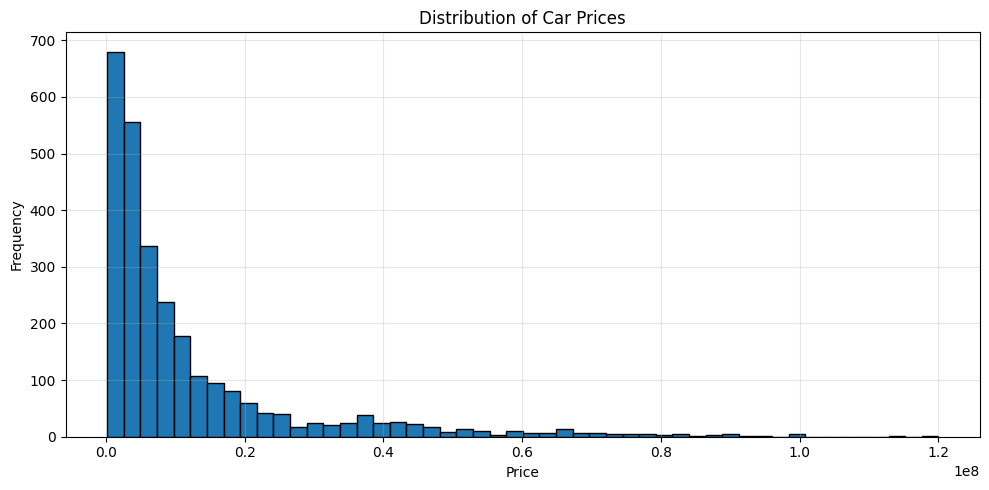

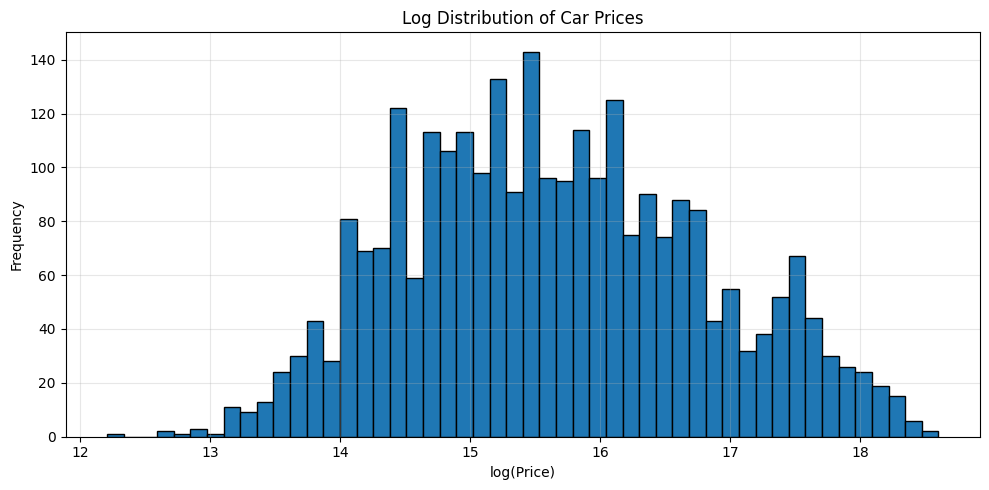

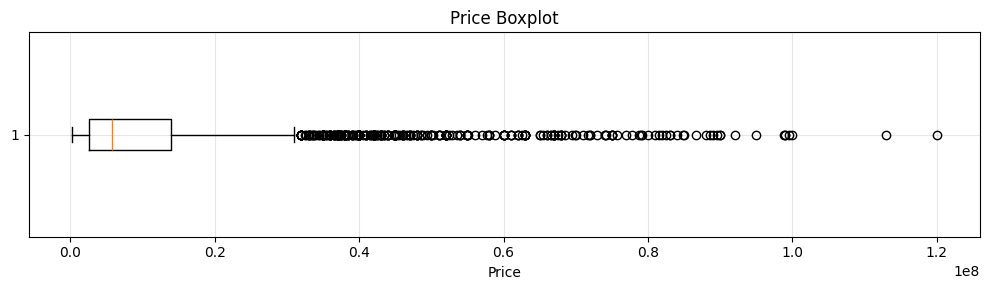

In [8]:


print("=" * 80)
print("PRICE DISTRIBUTION")
print("=" * 80)

if "price" in df.columns:
    price_data = df["price"].dropna()

    print("Price skewness:", round(price_data.skew(), 3))
    print("Log Price skewness:", round(np.log1p(price_data).skew(), 3))

    plt.figure(figsize=(10, 5))
    plt.hist(price_data, bins=50, edgecolor="black")
    plt.title("Distribution of Car Prices")
    plt.xlabel("Price")
    plt.ylabel("Frequency")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/price_distribution.png", dpi=300)
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.hist(np.log1p(price_data), bins=50, edgecolor="black")
    plt.title("Log Distribution of Car Prices")
    plt.xlabel("log(Price)")
    plt.ylabel("Frequency")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/log_price_distribution.png", dpi=300)
    plt.show()

    plt.figure(figsize=(10, 3))
    plt.boxplot(price_data, vert=False)
    plt.title("Price Boxplot")
    plt.xlabel("Price")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/price_boxplot.png", dpi=300)
    plt.show()

CORRELATION ANALYSIS
Correlation matrix:


,price,year,volume,car_age
price,1.00,0.74,0.25,-0.74
year,0.74,1.00,0.19,-1.00
volume,0.25,0.19,1.00,-0.19
car_age,-0.74,-1.00,-0.19,1.00



Correlation with Price:


,price
price,1.00
year,0.74
volume,0.25
car_age,-0.74


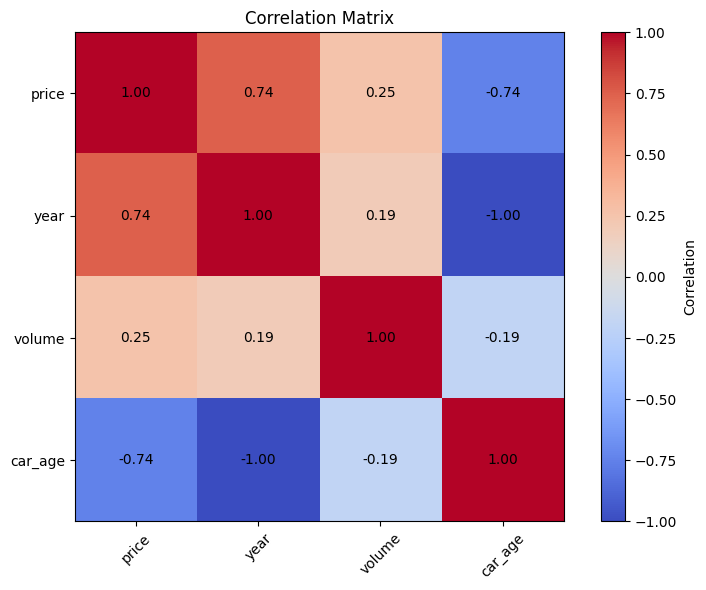

In [9]:


print("=" * 80)
print("CORRELATION ANALYSIS")
print("=" * 80)

if len(numeric_cols) > 1:
    corr_matrix = df[numeric_cols].corr()

    print("Correlation matrix:")
    display(corr_matrix)

    corr_matrix.to_csv(f"{OUTPUT_DIR}/correlation_matrix.csv")

    if "price" in numeric_cols:
        print("\nCorrelation with Price:")
        price_corr = corr_matrix["price"].sort_values(ascending=False)
        display(price_corr)

        price_corr.to_csv(
            f"{OUTPUT_DIR}/correlation_with_price.csv",
            header=["correlation"]
        )

    plt.figure(figsize=(8, 6))
    plt.imshow(corr_matrix, cmap="coolwarm", interpolation="nearest")
    plt.colorbar(label="Correlation")

    plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45)
    plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

    for i in range(len(corr_matrix.columns)):
        for j in range(len(corr_matrix.columns)):
            plt.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center")

    plt.title("Correlation Matrix")
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/correlation_matrix.png", dpi=300)
    plt.show()

SCATTERPLOTS WITH PRICE


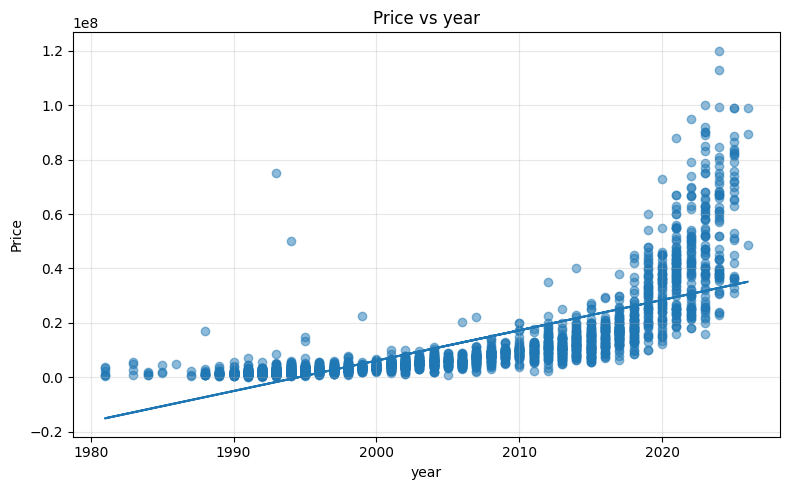

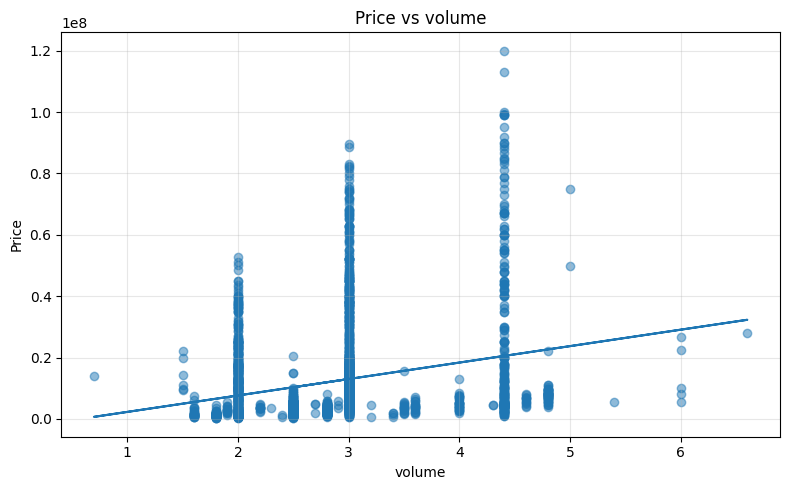

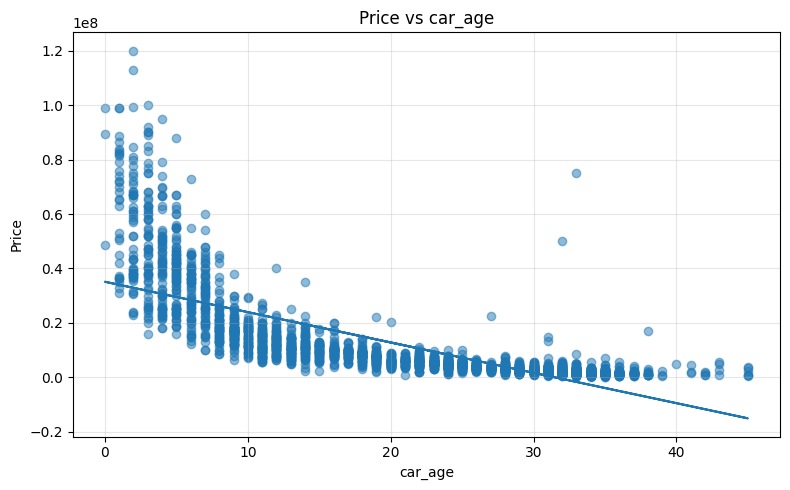

In [10]:


print("=" * 80)
print("SCATTERPLOTS WITH PRICE")
print("=" * 80)

if "price" in numeric_cols:
    for col in numeric_cols:
        if col != "price":
            clean_data = df[[col, "price"]].dropna()

            if len(clean_data) == 0:
                continue

            safe_col = col.replace("/", "_").replace("\\", "_").replace(" ", "_")

            plt.figure(figsize=(8, 5))
            plt.scatter(clean_data[col], clean_data["price"], alpha=0.5)

            if len(clean_data) > 1:
                z = np.polyfit(clean_data[col], clean_data["price"], 1)
                p = np.poly1d(z)
                plt.plot(clean_data[col], p(clean_data[col]))

            plt.title(f"Price vs {col}")
            plt.xlabel(col)
            plt.ylabel("Price")
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.savefig(f"{OUTPUT_DIR}/scatter_price_vs_{safe_col}.png", dpi=300)
            plt.show()

GROUP-BY ANALYSIS

--------------------------------------------------------------------------------
Average price by model:


,count,mean_price,median_price,min_price,max_price
model,,,,,
X5 M60i,1,"86,626,014.00","86,626,014.00",86626014,86626014
X7 XDrive 40i,1,"81,461,737.00","81,461,737.00",81461737,81461737
X6 XDrive 40i,2,"72,939,833.50","72,939,833.50",71731365,74148302
850,9,"62,944,444.44","67,000,000.00",45000000,79000000
M8,2,"60,500,000.00","60,500,000.00",54000000,67000000
X7,76,"56,038,672.24","52,000,000.00",31000000,99500000
M4,3,"54,666,666.67","52,000,000.00",52000000,60000000
M5,23,"53,785,304.35","44,800,000.00",14000000,113000000
X3 XDrive 20i,1,"52,882,594.00","52,882,594.00",52882594,52882594


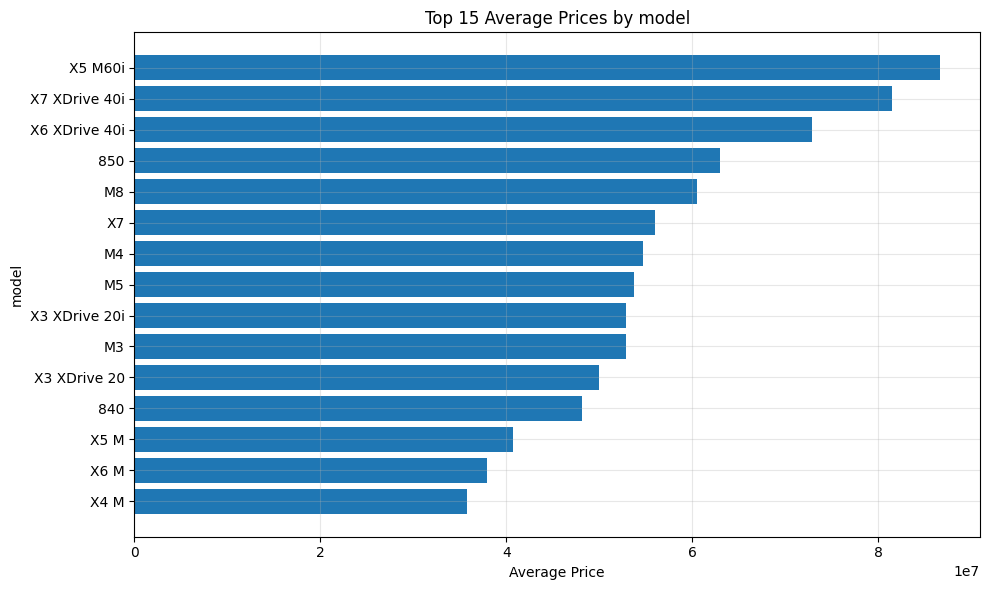


--------------------------------------------------------------------------------
Average price by body_type:


,count,mean_price,median_price,min_price,max_price
body_type,,,,,
кроссовер,749,"22,819,927.64","14,300,000.00",2120000,120000000
купе,56,"17,042,660.70","7,350,000.00",600000,79000000
кабриолет,8,"15,787,500.00","9,500,000.00",7000000,60000000
лифтбек,27,"13,142,592.59","12,000,000.00",7950000,37000000
родстер,6,"10,458,333.33","5,750,000.00",4100000,25000000
седан,1858,"7,748,116.40","3,600,000.00",200000,113000000
универсал,35,"6,525,714.26","4,000,000.00",1100000,63000000
хэтчбек,15,"4,111,333.33","3,500,000.00",900000,13900000


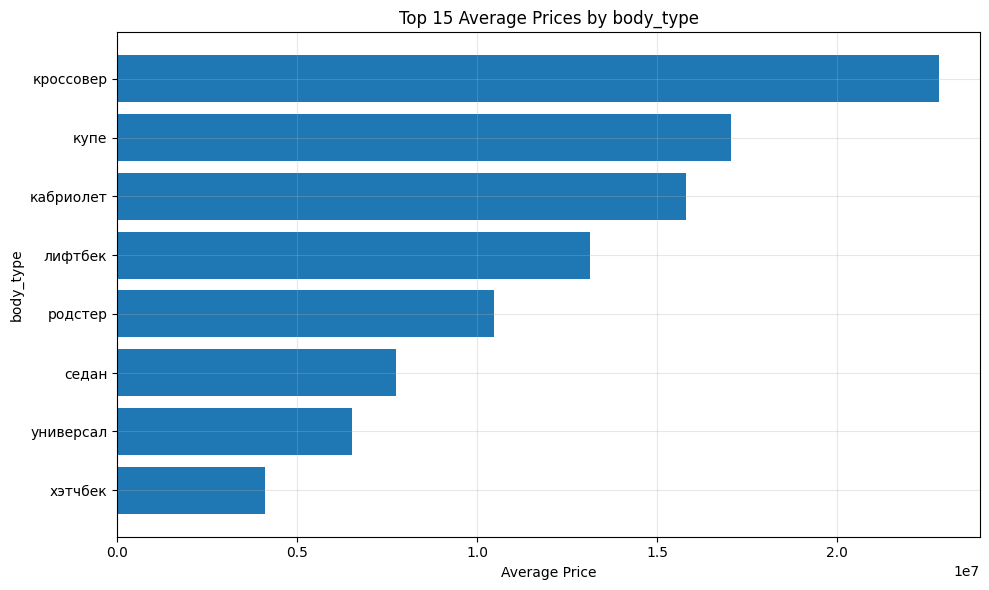


--------------------------------------------------------------------------------
Average price by fuel:


,count,mean_price,median_price,min_price,max_price
fuel,,,,,
гибрид,23,"47,175,870.91","40,000,000.00",1000000,113000000
дизель,43,"12,143,488.37","9,000,000.00",770000,51200000
бензин,2664,"11,858,378.39","5,600,000.00",200000,120000000
газ-бензин,24,"3,272,916.67","2,750,000.00",1600000,7500000


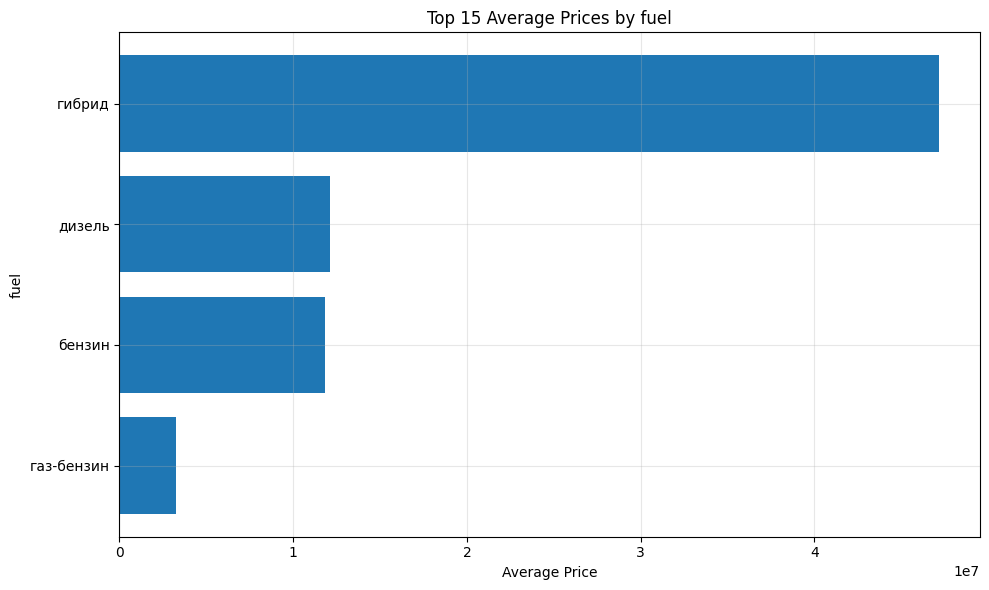


--------------------------------------------------------------------------------
Average price by gearbox:


,count,mean_price,median_price,min_price,max_price
gearbox,,,,,
робот,19,"22,152,631.58","22,000,000.00",9800000,40000000
автомат,2030,"15,336,604.99","8,675,000.00",400000,120000000
вариатор,1,"3,500,000.00","3,500,000.00",3500000,3500000
механика,704,"2,441,444.52","1,900,000.00",200000,75000000


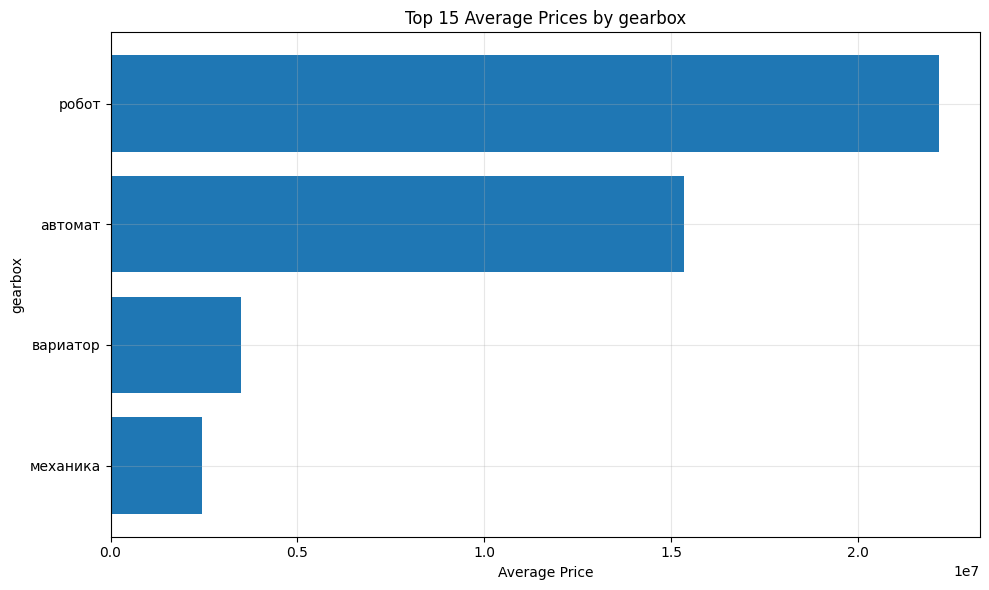


--------------------------------------------------------------------------------
Average price by type:


,count,mean_price,median_price,min_price,max_price
type,,,,,
новый,12,"61,407,844.50","62,306,979.50",2600000,99000000
Б/у,2742,"11,867,101.00","5,700,000.00",200000,120000000


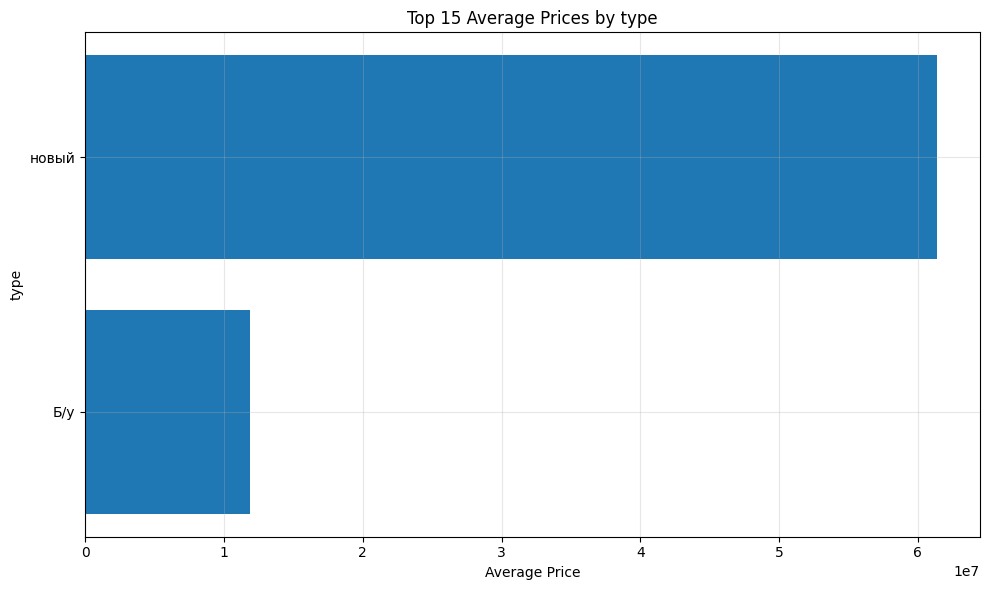

In [11]:

print("=" * 80)
print("GROUP-BY ANALYSIS")
print("=" * 80)

def group_price_analysis(dataframe, column):
    return (
        dataframe.groupby(column)
        .agg(
            count=("price", "count"),
            mean_price=("price", "mean"),
            median_price=("price", "median"),
            min_price=("price", "min"),
            max_price=("price", "max")
        )
        .sort_values("mean_price", ascending=False)
    )

group_columns = ["model", "body_type", "fuel", "gearbox", "type"]

if "price" in df.columns:
    for col in group_columns:
        print("\n" + "-" * 80)
        print(f"Average price by {col}:")

        result = group_price_analysis(df, col)
        display(result.head(15))

        safe_col = col.replace("/", "_").replace("\\", "_").replace(" ", "_")

        result.to_csv(f"{OUTPUT_DIR}/groupby_price_by_{safe_col}.csv")

        top_result = result.head(15).sort_values("mean_price")

        plt.figure(figsize=(10, 6))
        plt.barh(top_result.index.astype(str), top_result["mean_price"])
        plt.title(f"Top 15 Average Prices by {col}")
        plt.xlabel("Average Price")
        plt.ylabel(col)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(f"{OUTPUT_DIR}/groupby_price_by_{safe_col}.png", dpi=300)
        plt.show()

YEAR ANALYSIS


,count,mean_price,median_price,mean_volume
year,,,,
1981,6,"2,058,333.33","1,750,000.00",2.07
1983,4,"3,512,500.00","3,900,000.00",2.73
1984,4,"1,325,000.00","1,250,000.00",2.40
1985,3,"2,700,000.00","1,800,000.00",2.33
1986,1,"5,000,000.00","5,000,000.00",2.70
1987,3,"1,156,666.67","770,000.00",2.30
1988,14,"2,517,857.14","1,250,000.00",2.44
1989,26,"1,642,307.65","1,525,000.00",2.30
1990,48,"1,601,469.90","1,400,000.00",2.31


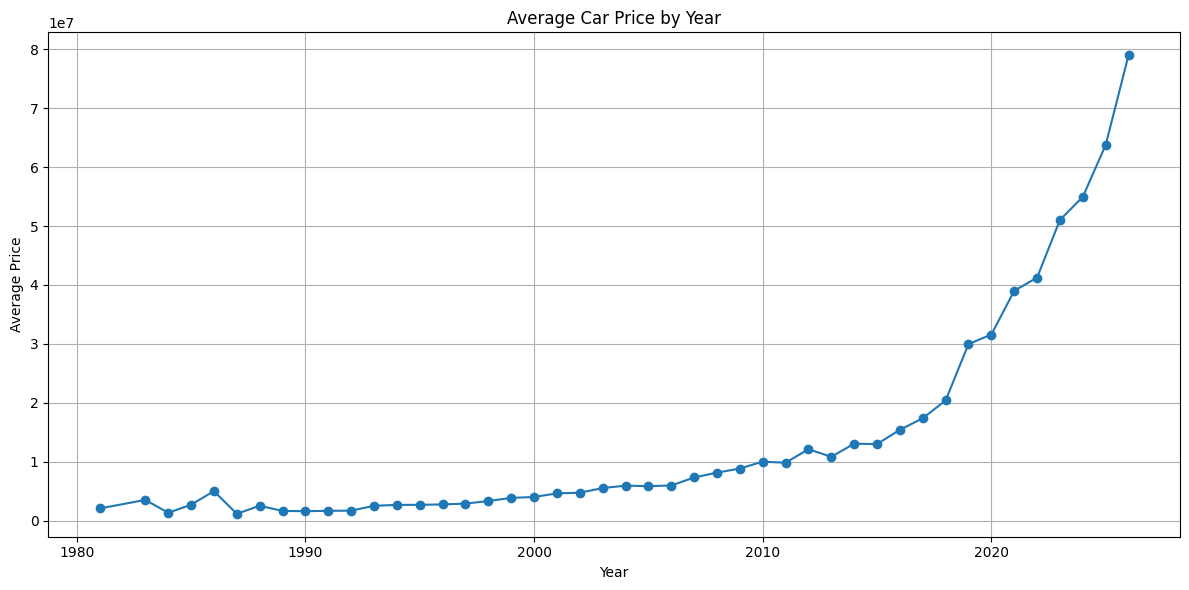

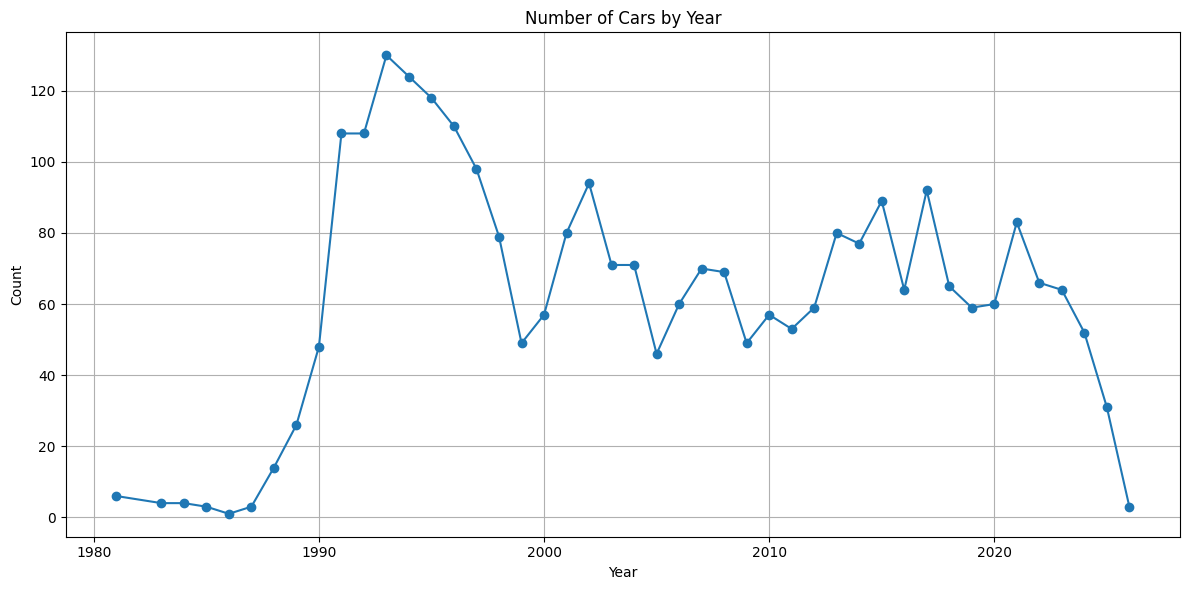

In [12]:


print("=" * 80)
print("YEAR ANALYSIS")
print("=" * 80)

if all(col in df.columns for col in ["year", "price"]):
    year_price = (
        df.groupby("year")
        .agg(
            count=("price", "count"),
            mean_price=("price", "mean"),
            median_price=("price", "median"),
            mean_volume=("volume", "mean")
        )
        .sort_index()
    )

    display(year_price)

    year_price.to_csv(f"{OUTPUT_DIR}/year_analysis.csv")

    plt.figure(figsize=(12, 6))
    plt.plot(year_price.index, year_price["mean_price"], marker="o")
    plt.title("Average Car Price by Year")
    plt.xlabel("Year")
    plt.ylabel("Average Price")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/average_price_by_year.png", dpi=300)
    plt.show()

    plt.figure(figsize=(12, 6))
    plt.plot(year_price.index, year_price["count"], marker="o")
    plt.title("Number of Cars by Year")
    plt.xlabel("Year")
    plt.ylabel("Count")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/number_of_cars_by_year.png", dpi=300)
    plt.show()

In [13]:


print("=" * 80)
print("TOP-N AND BOTTOM-N RECORDS")
print("=" * 80)

if "price" in df.columns:
    top_expensive = df.sort_values("price", ascending=False).head(10)
    top_cheapest = df.sort_values("price", ascending=True).head(10)

    print("\nTop 10 most expensive cars:")
    display(top_expensive)

    print("\nTop 10 cheapest cars:")
    display(top_cheapest)

    top_expensive.to_csv(f"{OUTPUT_DIR}/top_10_expensive.csv", index=False)
    top_cheapest.to_csv(f"{OUTPUT_DIR}/top_10_cheapest.csv", index=False)

if "year" in df.columns:
    top_newest = df.sort_values("year", ascending=False).head(10)
    top_oldest = df.sort_values("year", ascending=True).head(10)

    print("\nTop 10 newest cars:")
    display(top_newest)

    print("\nTop 10 oldest cars:")
    display(top_oldest)

    top_newest.to_csv(f"{OUTPUT_DIR}/top_10_newest.csv", index=False)
    top_oldest.to_csv(f"{OUTPUT_DIR}/top_10_oldest.csv", index=False)

if "volume" in df.columns:
    top_volume = df.sort_values("volume", ascending=False).head(10)

    print("\nTop 10 cars with largest engine volume:")
    display(top_volume)

    top_volume.to_csv(f"{OUTPUT_DIR}/top_10_largest_engine_volume.csv", index=False)

TOP-N AND BOTTOM-N RECORDS

Top 10 most expensive cars:


,title,brand,model,price,year,body_type,volume,fuel,gearbox,type,car_age
468,BMW X6 M,BMW,X6 M,120000000,2024,кроссовер,4.40,бензин,автомат,Б/у,2
1160,BMW M5,BMW,M5,113000000,2024,седан,4.40,гибрид,автомат,Б/у,2
1617,BMW X6 M,BMW,X6 M,100000000,2023,кроссовер,4.40,бензин,автомат,Б/у,3
1618,BMW X7,BMW,X7,99500000,2024,кроссовер,4.40,бензин,автомат,Б/у,2
2320,BMW M5,BMW,M5,99000000,2025,седан,4.40,гибрид,автомат,Б/у,1
1414,BMW M5,BMW,M5,99000000,2026,седан,4.40,гибрид,автомат,новый,0
2168,BMW M5,BMW,M5,98900000,2025,седан,4.40,гибрид,автомат,Б/у,1
720,BMW 760,BMW,760,95000000,2022,седан,4.40,бензин,автомат,Б/у,4
978,BMW X5 M,BMW,X5 M,92000000,2023,кроссовер,4.40,бензин,автомат,Б/у,3
2533,BMW X7,BMW,X7,90000000,2023,кроссовер,4.40,бензин,автомат,Б/у,3



Top 10 cheapest cars:


,title,brand,model,price,year,body_type,volume,fuel,gearbox,type,car_age
2095,BMW 318,BMW,318,200000,1991,седан,1.80,бензин,механика,Б/у,35
640,BMW 318,BMW,318,300000,1991,седан,1.80,бензин,механика,Б/у,35
923,BMW 318,BMW,318,301500,1992,седан,1.80,бензин,механика,Б/у,34
948,BMW 525,BMW,525,340000,1990,седан,2.50,бензин,механика,Б/у,36
2584,BMW 318,BMW,318,400000,1995,седан,1.80,бензин,автомат,Б/у,31
1077,BMW 520,BMW,520,400000,1987,седан,2.00,бензин,механика,Б/у,39
131,BMW 520,BMW,520,400000,1992,седан,2.00,бензин,механика,Б/у,34
1193,BMW 525,BMW,525,450000,1991,седан,2.50,бензин,механика,Б/у,35
1660,BMW 535,BMW,535,500000,1994,седан,3.40,бензин,механика,Б/у,32
2333,BMW 318,BMW,318,500000,1989,седан,1.80,бензин,механика,Б/у,37



Top 10 newest cars:


,title,brand,model,price,year,body_type,volume,fuel,gearbox,type,car_age
1414,BMW M5,BMW,M5,99000000,2026,седан,4.40,гибрид,автомат,новый,0
1502,BMW X6,BMW,X6,89500000,2026,кроссовер,3.00,бензин,автомат,Б/у,0
1392,BMW X3 XDrive 20,BMW,X3 XDrive 20,48500000,2026,кроссовер,2.00,бензин,автомат,новый,0
2303,BMW 320,BMW,320,31000000,2025,седан,2.00,бензин,автомат,Б/у,1
731,BMW X7,BMW,X7,79200000,2025,кроссовер,3.00,бензин,автомат,Б/у,1
2297,BMW X3 XDrive 20,BMW,X3 XDrive 20,50287092,2025,кроссовер,2.00,гибрид,автомат,новый,1
2633,BMW X5,BMW,X5,63000000,2025,кроссовер,3.00,бензин,автомат,Б/у,1
525,BMW X5,BMW,X5,65500000,2025,кроссовер,3.00,бензин,автомат,Б/у,1
1754,BMW X7,BMW,X7,83000000,2025,кроссовер,3.00,бензин,автомат,Б/у,1
2027,BMW X3,BMW,X3,37368421,2025,кроссовер,2.00,бензин,автомат,Б/у,1



Top 10 oldest cars:


,title,brand,model,price,year,body_type,volume,fuel,gearbox,type,car_age
1237,BMW 318,BMW,318,1000000,1981,седан,1.80,бензин,механика,Б/у,45
2195,BMW 525,BMW,525,1000000,1981,седан,2.50,бензин,механика,Б/у,45
2302,BMW 520,BMW,520,550000,1981,седан,2.00,бензин,механика,Б/у,45
2351,BMW 320,BMW,320,3800000,1981,седан,2.00,бензин,механика,Б/у,45
2110,BMW 318,BMW,318,2500000,1981,седан,1.80,бензин,механика,Б/у,45
1915,BMW 323,BMW,323,3500000,1981,седан,2.30,бензин,механика,Б/у,45
299,BMW 525,BMW,525,2800000,1983,седан,2.50,бензин,механика,Б/у,43
1656,BMW 732,BMW,732,750000,1983,седан,3.20,бензин,автомат,Б/у,43
2420,BMW 525,BMW,525,5500000,1983,седан,2.50,бензин,механика,Б/у,43
2328,BMW 528,BMW,528,5000000,1983,седан,2.70,бензин,механика,Б/у,43



Top 10 cars with largest engine volume:


,title,brand,model,price,year,body_type,volume,fuel,gearbox,type,car_age
426,BMW M760,BMW,M760,28000000,2018,седан,6.60,бензин,автомат,Б/у,8
2021,BMW 760,BMW,760,8000000,2006,седан,6.00,бензин,автомат,Б/у,20
1183,BMW 760,BMW,760,22500000,1999,седан,6.00,бензин,автомат,Б/у,27
1539,BMW 760,BMW,760,5500000,2007,седан,6.00,бензин,автомат,Б/у,19
1174,BMW 760,BMW,760,26700800,2015,седан,6.00,бензин,автомат,Б/у,11
149,BMW 760,BMW,760,10000000,2009,седан,6.00,бензин,автомат,Б/у,17
49,BMW 750,BMW,750,5500000,1996,седан,5.40,бензин,автомат,Б/у,30
1044,BMW 850,BMW,850,50000000,1994,купе,5.00,бензин,механика,Б/у,32
211,BMW 850,BMW,850,75000000,1993,купе,5.00,бензин,механика,Б/у,33
613,BMW X5,BMW,X5,8800000,2008,кроссовер,4.80,бензин,автомат,Б/у,18


HYPOTHESIS 1
Hypothesis 1: Newer cars are more expensive.
Correlation between year and price: 0.745
Conclusion: Supported. Newer cars generally have higher prices.


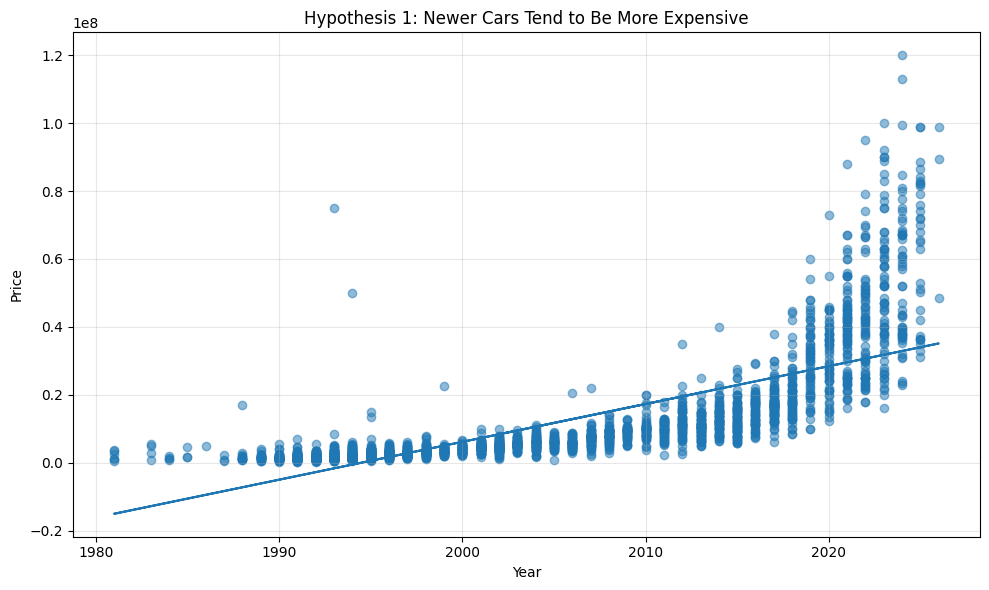

In [14]:

print("=" * 80)
print("HYPOTHESIS 1")
print("=" * 80)

print("Hypothesis 1: Newer cars are more expensive.")

if all(col in df.columns for col in ["year", "price"]):
    clean_data = df[["year", "price"]].dropna()

    corr_year_price = clean_data["year"].corr(clean_data["price"])

    print(f"Correlation between year and price: {corr_year_price:.3f}")

    if corr_year_price > 0:
        print("Conclusion: Supported. Newer cars generally have higher prices.")
    else:
        print("Conclusion: Not supported.")

    plt.figure(figsize=(10, 6))
    plt.scatter(clean_data["year"], clean_data["price"], alpha=0.5)

    if len(clean_data) > 1:
        z = np.polyfit(clean_data["year"], clean_data["price"], 1)
        p = np.poly1d(z)
        plt.plot(clean_data["year"], p(clean_data["year"]))

    plt.title("Hypothesis 1: Newer Cars Tend to Be More Expensive")
    plt.xlabel("Year")
    plt.ylabel("Price")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/hypothesis_1_year_price.png", dpi=300)
    plt.show()

HYPOTHESIS 2
Hypothesis 2: Cars with larger engine volume are more expensive.
Correlation between engine volume and price: 0.253
Conclusion: Supported. Larger engine volume is associated with higher prices.


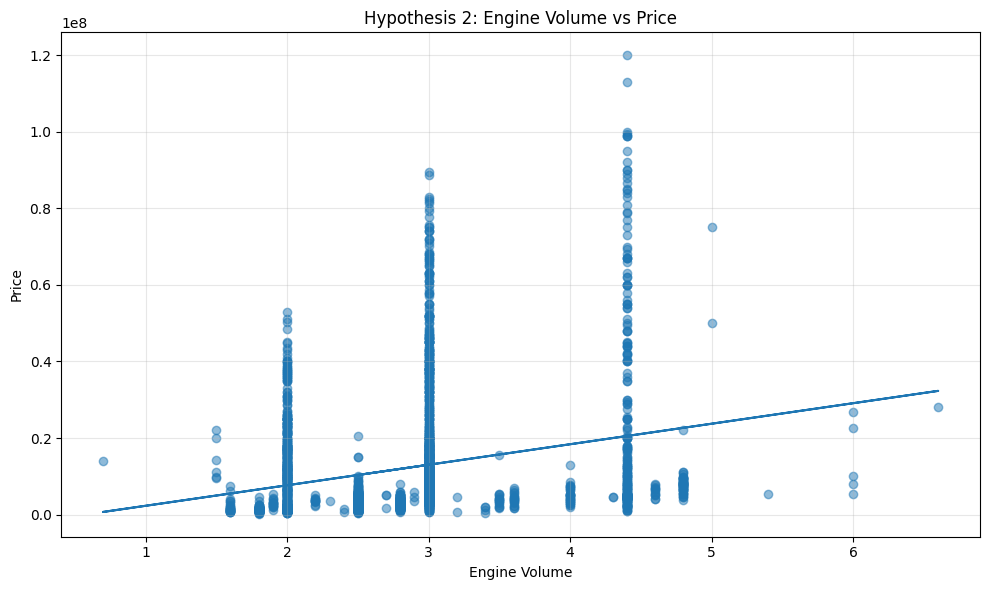

In [15]:

print("=" * 80)
print("HYPOTHESIS 2")
print("=" * 80)

print("Hypothesis 2: Cars with larger engine volume are more expensive.")

if all(col in df.columns for col in ["volume", "price"]):
    clean_data = df[["volume", "price"]].dropna()

    corr_volume_price = clean_data["volume"].corr(clean_data["price"])

    print(f"Correlation between engine volume and price: {corr_volume_price:.3f}")

    if corr_volume_price > 0:
        print("Conclusion: Supported. Larger engine volume is associated with higher prices.")
    else:
        print("Conclusion: Not supported.")

    plt.figure(figsize=(10, 6))
    plt.scatter(clean_data["volume"], clean_data["price"], alpha=0.5)

    if len(clean_data) > 1:
        z = np.polyfit(clean_data["volume"], clean_data["price"], 1)
        p = np.poly1d(z)
        plt.plot(clean_data["volume"], p(clean_data["volume"]))

    plt.title("Hypothesis 2: Engine Volume vs Price")
    plt.xlabel("Engine Volume")
    plt.ylabel("Price")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/hypothesis_2_volume_price.png", dpi=300)
    plt.show()

HYPOTHESIS 3
Hypothesis 3: Automatic transmission cars are more expensive than manual transmission cars.

Average price by gearbox:


,count,mean_price,median_price,min_price,max_price
gearbox,,,,,
робот,19,"22,152,631.58","22,000,000.00",9800000,40000000
автомат,2030,"15,336,604.99","8,675,000.00",400000,120000000
вариатор,1,"3,500,000.00","3,500,000.00",3500000,3500000
механика,704,"2,441,444.52","1,900,000.00",200000,75000000



Automatic transmission average price: 15,336,604.99
Manual transmission average price: 2,441,444.52
Conclusion: Supported. Automatic transmission cars are more expensive on average.


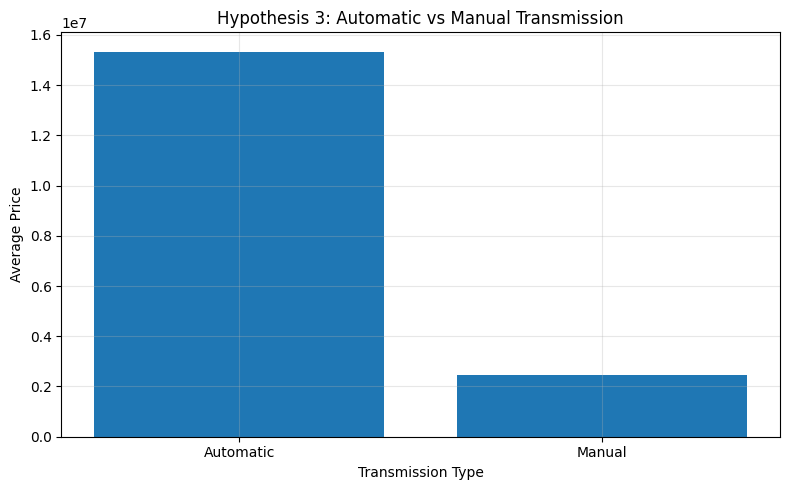

In [16]:


print("=" * 80)
print("HYPOTHESIS 3")
print("=" * 80)

print("Hypothesis 3: Automatic transmission cars are more expensive than manual transmission cars.")

if all(col in df.columns for col in ["gearbox", "price"]):
    gearbox_price = group_price_analysis(df, "gearbox")

    print("\nAverage price by gearbox:")
    display(gearbox_price)

    gearbox_price.to_csv(f"{OUTPUT_DIR}/hypothesis_3_gearbox_price.csv")

    gearbox_lower = df["gearbox"].astype(str).str.lower()

    automatic_mask = gearbox_lower.str.contains("автомат|automatic|auto|акпп", na=False)
    manual_mask = gearbox_lower.str.contains("механика|manual|мкпп", na=False)

    automatic_data = df[automatic_mask]
    manual_data = df[manual_mask]

    automatic_mean = automatic_data["price"].mean()
    manual_mean = manual_data["price"].mean()

    print(f"\nAutomatic transmission average price: {automatic_mean:,.2f}")
    print(f"Manual transmission average price: {manual_mean:,.2f}")

    if automatic_mean > manual_mean:
        print("Conclusion: Supported. Automatic transmission cars are more expensive on average.")
    else:
        print("Conclusion: Not supported.")

    plt.figure(figsize=(8, 5))
    plt.bar(["Automatic", "Manual"], [automatic_mean, manual_mean])
    plt.title("Hypothesis 3: Automatic vs Manual Transmission")
    plt.xlabel("Transmission Type")
    plt.ylabel("Average Price")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/hypothesis_3_automatic_manual_price.png", dpi=300)
    plt.show()

In [17]:
print("=" * 80)
print("FINAL SUMMARY")
print("=" * 80)

print(f"The dataset contains {df.shape[0]} rows and {df.shape[1]} columns.")

print("\nNumerical columns:")
print(numeric_cols)

print("\nCategorical columns:")
print(categorical_cols)

if "price" in df.columns:
    print("\nAverage price:")
    print(f"{df['price'].mean():,.2f}")

    print("\nMedian price:")
    print(f"{df['price'].median():,.2f}")

    print("\nMinimum price:")
    print(f"{df['price'].min():,.2f}")

    print("\nMaximum price:")
    print(f"{df['price'].max():,.2f}")

if "volume" in df.columns:
    print("\nAverage engine volume:")
    print(f"{df['volume'].mean():,.2f}")

    print("\nMedian engine volume:")
    print(f"{df['volume'].median():,.2f}")

if "price" in df.columns and len(df.select_dtypes(include=["int64", "float64"]).columns) > 1:
    print("\nStrongest correlations with price:")
    display(df.select_dtypes(include=["int64", "float64"]).corr()["price"].sort_values(ascending=False))

print("\nMain conclusions:")
print("1. The dataset contains car listings with information about title, brand, model, price, year, body type, engine volume, fuel, gearbox, and type.")
print("2. Descriptive statistics were calculated for all numerical variables.")
print("3. The price distribution was analyzed to identify skewness and potential outliers.")
print("4. Correlation analysis shows how price is related to year, engine volume, and car age.")
print("5. Group-by analysis shows that average prices differ by brand, model, body type, fuel type, gearbox, and car type.")
print("6. Top-N and bottom-N records helped identify unusually expensive, cheap, old, new, and large-engine cars.")
print("7. Several hypotheses were tested using correlations, group comparisons, and visualizations.")

df.to_csv(f"{OUTPUT_DIR}/kolesa_final_with_eda_features.csv", index=False)

FINAL SUMMARY
The dataset contains 2754 rows and 11 columns.

Numerical columns:
['price', 'year', 'volume', 'car_age']

Categorical columns:
['title', 'brand', 'model', 'body_type', 'fuel', 'gearbox', 'type']

Average price:
12,082,964.80

Median price:
5,700,000.00

Minimum price:
200,000.00

Maximum price:
120,000,000.00

Average engine volume:
2.83

Median engine volume:
3.00

Strongest correlations with price:


,price
price,1.00
year,0.74
volume,0.25
car_age,-0.74



Main conclusions:
1. The dataset contains car listings with information about title, brand, model, price, year, body type, engine volume, fuel, gearbox, and type.
2. Descriptive statistics were calculated for all numerical variables.
3. The price distribution was analyzed to identify skewness and potential outliers.
4. Correlation analysis shows how price is related to year, engine volume, and car age.
5. Group-by analysis shows that average prices differ by brand, model, body type, fuel type, gearbox, and car type.
6. Top-N and bottom-N records helped identify unusually expensive, cheap, old, new, and large-engine cars.
7. Several hypotheses were tested using correlations, group comparisons, and visualizations.
